In [1]:
import os
import json
from tqdm import tqdm

import numpy as np

os.environ["JAX_PLATFORMS"] = "cpu"
import jax
import jax.numpy as jnp

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

from utils import load_pass_curves
from utils import threshold_to_profit_batch
from utils import cost_for_pass, get_arbitrage_prices

In [2]:
base_dir = "../data/lean/"

results = {}
for file in os.listdir(base_dir):
    if not file.endswith(".jsonl"):
        continue

    model_name = file.split(".jsonl")[0]
    data = [json.loads(line) for line in open(os.path.join(base_dir, file), "r")]
    results[model_name] = data

## Figure 1

In [3]:
budget_grid = np.logspace(np.log10(2e3), np.log10(3e8), 250)
models = ['kimina-0.6b', 'kimina-1.7b', 'kimina-8b', 'kimina-72b']
providers_perf = load_pass_curves(results, models, budget_grid)

Search for optimal arbitrage via grid search

In [4]:
max_budget = 1e9
computes = np.r_[0, np.logspace(np.log10(1e4), np.log10(1e9), 20)]
X1, X2, X3, X4 = np.meshgrid(
    computes, computes, computes, computes,
    indexing="ij"
)

points = np.stack((X1, X2, X3, X4), axis=-1).reshape(-1, 4)

# filtering...
def enforce_row_sum(points, X):
    points = points.copy()
    
    row_sums = points.sum(axis=1)
    excess = np.maximum(row_sums - X, 0.0)  # only positive excess
    
    # Go from last column to first
    for j in reversed(range(points.shape[1])):
        reduction = np.minimum(points[:, j], excess)
        points[:, j] -= reduction
        excess -= reduction
    
    return points

points = enforce_row_sum(points, max_budget)
points = np.unique(np.round(points, decimals=8), axis=0)

def is_monotonic_ignore_zeros(arr):
    # 1. Create a copy to avoid modifying original data
    temp = arr.copy()
    
    # 2. Forward fill zeros with the previous element's value
    # This ensures zeros don't trigger a "decrease" or "increase" 
    # relative to the elements around them.
    for i in range(1, temp.shape[1]):
        mask = temp[:, i] == 0
        temp[mask, i] = temp[mask, i-1]

    # 3. Calculate differences on the filled array
    diffs = np.diff(temp, axis=1)
    
    # 4. Check for monotonicity (>= 0 allows the "filled" zeros to pass)
    # We also need to ensure the non-zero values actually increased.
    # A simple way is to check if the sequence is non-decreasing.
    return np.all(diffs >= 0, axis=1)

mask = is_monotonic_ignore_zeros(points)
points = points[mask]

In [5]:
performance_grid = jnp.linspace(0.6, 0.9, 100)
prices_vmap = jax.vmap(get_arbitrage_prices, in_axes=(None, None, 0, None))
arbitrage_cost_all, arbitrage_expend_all = prices_vmap(budget_grid, providers_perf, points, performance_grid)

In [6]:
# expenditure and cost across the performance levels
idsmin = np.argmin(arbitrage_cost_all, axis=0)
arbitrage_expend = arbitrage_expend_all[idsmin, :, np.arange(idsmin.shape[0])]

arbitrage_cost = arbitrage_cost_all.min(axis=0)
provider_prices = np.array([
    cost_for_pass(budget_grid, p, performance_grid)
    for p in providers_perf.mean(axis=0)
])

market_price = provider_prices.min(axis=0)
profit = market_price - arbitrage_cost
profit = np.maximum(0, profit)
profit_margin = profit / market_price

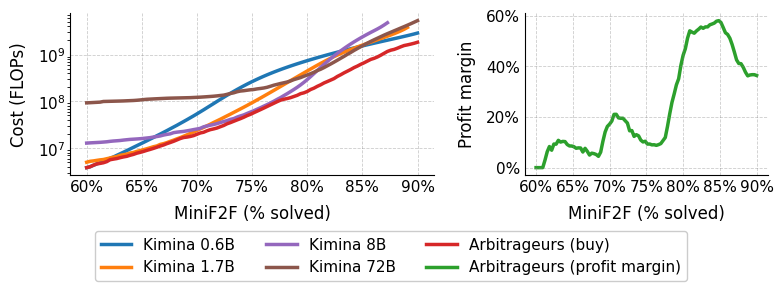

In [7]:
prefix = '/home/'

fig, axs = plt.subplots(1, 2, 
    figsize=(9, 2.1), 
    gridspec_kw={'width_ratios': [1.5, 1]}, sharex=True
)

linewidth = 2.5
alpha = 1.0
palette = sns.color_palette()
colors = [
    palette[0],
    palette[1],
    palette[4],
    palette[5],
]

model_names = {
    'kimina-0.6b': 'Kimina 0.6B',
    'kimina-1.7b': 'Kimina 1.7B',
    'kimina-8b': 'Kimina 8B',
    'kimina-72b': 'Kimina 72B',
}

ax = axs[0]
for i in range(provider_prices.shape[0]):
    ax.plot(
        performance_grid,
        provider_prices[i]*244,
        label=model_names[models[i]],
        linewidth=linewidth,
        alpha=alpha,
    color=colors[i],
    zorder=6,
)

ax.plot(
    performance_grid,
    arbitrage_cost*244,
    linewidth=linewidth,
    alpha=alpha,
    color=palette[3],
    label="Arbitrageur (buy)",
    zorder=7,
)

ax = axs[1]

ax.plot(
    performance_grid,
    profit_margin,
    color=palette[2],
    linewidth=linewidth,
    alpha=alpha,
    zorder=-1,
    label="Arbitrageur (sell)",
    # linestyle="--",
)

def format_ax(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.8)
    ax.spines["bottom"].set_linewidth(0.8)

    ax.grid(alpha=0.4, linewidth=0.6, linestyle="--", color="gray", zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(labelsize=11, direction="out", length=0, width=0.8)


for ax in axs:
    format_ax(ax)

axs[0].set_yscale('log')
axs[0].set_ylabel("Cost (FLOPs)", fontsize=12, fontweight="normal", labelpad=7)
axs[0].set_xlabel("MiniF2F (% solved)", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_xlabel("MiniF2F (% solved)", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_ylabel("Profit margin", fontsize=12, fontweight="normal", labelpad=7)

# axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x*244}"))
axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))


# legend elements...
legend_elements = [
    Line2D([0], [0], color=colors[0], linewidth=linewidth, label=model_names[models[0]]),
    Line2D([0], [0], color=colors[1], linewidth=linewidth, label=model_names[models[1]]),
    Line2D([0], [0], color=colors[2], linewidth=linewidth, label=model_names[models[2]]),
    Line2D([0], [0], color=colors[3], linewidth=linewidth, label=model_names[models[3]]),
    Line2D([0], [0], color=palette[3], linewidth=linewidth, label="Arbitrageurs (buy)"),
    Line2D([0], [0], color=palette[2], linewidth=linewidth, label="Arbitrageurs (profit margin)"),
]
# put below the plot
ax.legend(
    handles=legend_elements,
    loc="best",
    ncol=3,
    fontsize=11,
    framealpha=1.0,
    bbox_to_anchor=(0.7, -0.3),
)

fig.subplots_adjust(wspace=0.3)
plt.savefig(f"plots/kimina-fig1.pdf", bbox_inches="tight")

## Revenue share

First, get how the models split revenue when no arbitrage exists.

In [8]:
not_competitive = (provider_prices > market_price[None])
provider_revenue = np.where(not_competitive, 0, provider_prices)
provider_share = provider_revenue / provider_revenue.sum(axis=0)

Then, how models split revenue once the arbitrageur enters the market. Consider only the buy price of the arbitrageur.

In [9]:
arbitrage_better = (arbitrage_cost < market_price)
arbitrage_revenue = np.where(arbitrage_better[None], arbitrage_expend.T, provider_revenue)

# add one more row with the arbitrage profit
arbitrage_profit = np.maximum(0, market_price - arbitrage_cost)
arbitrage_revenue = np.concatenate([arbitrage_revenue, arbitrage_profit[None]])
arbitrage_share = arbitrage_revenue / arbitrage_revenue.sum(axis=0)

# consider the overall change in provider revenue
revenue_change = arbitrage_revenue[:-1].sum(axis=0) / provider_revenue.sum(axis=0)

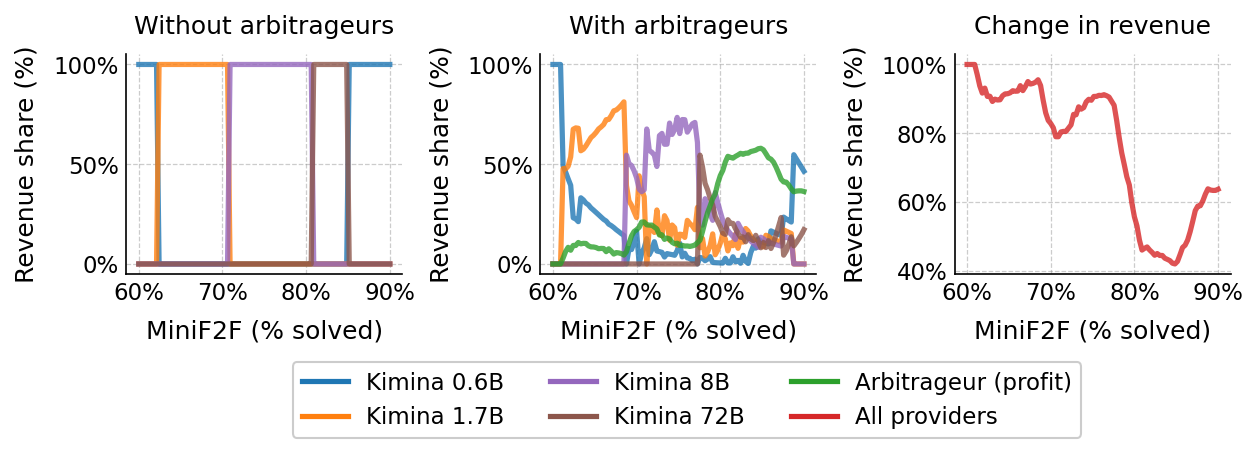

In [10]:
fig, axs = plt.subplots(1, 3, figsize=(9.5, 1.9), dpi=150, sharex=True)

alpha=0.8
linewidth=2.5

ax = axs[0]
for i in range(provider_share.shape[0]):
    ax.plot(performance_grid, provider_share[i], color=colors[i], linewidth=linewidth, alpha=alpha)

ax.set_title("Without arbitrageurs", fontsize=12, fontweight="500", pad=10)

ax = axs[1]
for i in range(arbitrage_share.shape[0]-1):
    ax.plot(performance_grid, arbitrage_share[i], color=colors[i], linewidth=linewidth, alpha=alpha)
ax.plot(performance_grid, arbitrage_share[-1], color=palette[2], linewidth=linewidth, alpha=alpha, zorder=10)
ax.set_title("With arbitrageurs", fontsize=12, fontweight="500", pad=10)
ax = axs[2]
ax.plot(
    performance_grid,
    revenue_change,
    color=palette[3],
    linewidth=linewidth,
    alpha=alpha,
)
# ax.set_xlim(0.75, performance_grid.max())
ax.set_title("Change in revenue", fontsize=12, fontweight="500", pad=10)

for ax in axs:
    format_ax(ax)

axs[0].set_ylabel("Revenue share (%)", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_ylabel("Revenue share (%)", fontsize=12, fontweight="normal", labelpad=7)
axs[2].set_ylabel("Revenue share (%)", fontsize=12, fontweight="normal", labelpad=7)

axs[0].set_xlabel("MiniF2F (% solved)", fontsize=12, fontweight="normal", labelpad=7)
axs[1].set_xlabel("MiniF2F (% solved)", fontsize=12, fontweight="normal", labelpad=7)
axs[2].set_xlabel("MiniF2F (% solved)", fontsize=12, fontweight="normal", labelpad=7)


axs[0].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:.0f}"))
axs[1].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"${x:.0f}"))
axs[2].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[0].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[1].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))
axs[2].xaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

# increase distance between each of the axs
fig.subplots_adjust(wspace=0.5)

# legend elements...
legend_elements = [
    Line2D([0], [0], color=colors[0], linewidth=linewidth, label=model_names[models[0]]),
    Line2D([0], [0], color=colors[1], linewidth=linewidth, label=model_names[models[1]]),
    Line2D([0], [0], color=colors[2], linewidth=linewidth, label=model_names[models[2]]),
    Line2D([0], [0], color=colors[3], linewidth=linewidth, label=model_names[models[3]]),
    Line2D([0], [0], color=palette[2], linewidth=linewidth, label="Arbitrageur (profit)"),
    Line2D([0], [0], color=palette[3], linewidth=linewidth, label="All providers"),
]
# put below the plot
ax.legend(
    handles=legend_elements,
    loc="best",
    ncol=3,
    fontsize=11,
    framealpha=1.0,
    bbox_to_anchor=(0.5, -0.35),
)

plt.savefig(f"plots/lean-fig2.pdf", bbox_inches="tight")

## Distillation

In [11]:
models = [
    'distill-1.7b-3k',
    'distill-1.7b-8k',
    'distill-1.7b-24k',
    'distill-1.7b-72k',
    'distill-1.7b-192k',
    'kimina-72b',
]

budget_grid = np.logspace(np.log10(2e3), np.log10(1e9), 250)
distill_perf = load_pass_curves(results, models, budget_grid)

# also for pass@k
budget_grid_k = np.arange(1, 101)
distill_perfk = load_pass_curves(results, models, budget_grid_k, cost_per_problem_override=1)

In [12]:
performance_grid = jnp.linspace(0.7, 0.9, 100)

# grid of compute allocations
max_budget = 1e9
compute_first = np.r_[0, np.logspace(np.log10(2e3), np.log10(max_budget), 100)]

compute_second = max_budget - compute_first
compute_allocation = np.stack([compute_first, compute_second], axis=-1)

Calculate the profitability of arbitrage when pairing each distilled model with Kimina 72B

In [13]:
# calculate the max profit 
profits1b = []
for i in tqdm(range(len(models)-1)):
    profit_grid = threshold_to_profit_batch(
        budget_grid,
        distill_perf[:, [i, -1]],
        compute_allocation,
        performance_grid,
    )
    # replace nan with 0
    profit_grid = np.where(np.isnan(profit_grid), 0, profit_grid)
    profit_grid = profit_grid.mean(axis=-1)
    max_profit = profit_grid.max()
    profits1b.append(max_profit)

100%|██████████| 5/5 [00:04<00:00,  1.21it/s]


In [14]:
performance_grid_plot = np.linspace(0.4, 0.8, 100)
provider_prices_plot = np.array([
    cost_for_pass(budget_grid, p, performance_grid_plot)
    for p in distill_perf.mean(axis=0)
])

/tmp/ipykernel_1293181/1874632968.py:33: UserWarning: marker is redundantly defined by the 'marker' keyword argument and the fmt string "o" (-> marker='o'). The keyword argument will take precedence.
  ax.plot(xx, yy, 'o', marker='o', linestyle='', markersize=8, linewidth=2.5,  markeredgewidth=0.8, color=palette[i])


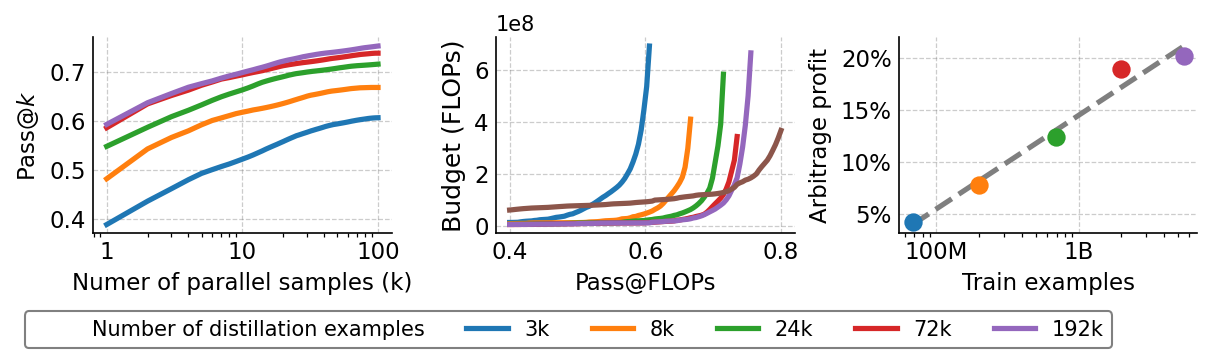

In [15]:
from matplotlib.ticker import FuncFormatter
import seaborn as sns
palette = sns.color_palette()

fig, axs = plt.subplots(1, 3, figsize=(9.5, 1.7), dpi=150)

labels = {
    'distill-1.7b-3k': '3k',
    'distill-1.7b-8k': '8k',
    'distill-1.7b-24k': '24k',
    'distill-1.7b-72k': '72k',
    'distill-1.7b-192k': '192k',
}

ax = axs[0]
for i, model in enumerate(models[:-1]):
    passk = distill_perfk[:, i].mean(axis=0)
    ax.plot(budget_grid_k, passk, linewidth=2.5, label=labels[model], color=palette[i])
ax.set_xscale("log")


ax = axs[1]
for i in range(provider_prices_plot.shape[0]):
    ax.plot(performance_grid_plot, provider_prices_plot[i]*244, linewidth=2.5, color=palette[i])

ax = axs[2]
steps = np.array([3, 8, 24, 72, 192])
examples = steps * 1000
examples = [6.8e7, 2e8, 6.9e8, 2e9, 5.5e9]
y = profits1b

for i, (xx, yy) in enumerate(zip(examples, y)):
    ax.plot(xx, yy, 'o', marker='o', linestyle='', markersize=8, linewidth=2.5,  markeredgewidth=0.8, color=palette[i])

a, b = np.polyfit(np.log(examples), y, 1)
xx = np.logspace(np.log10(examples[0]), np.log10(examples[-1]), 100)
yy = a * np.log(xx) + b
plt.plot(xx, yy, linestyle='--', linewidth=2.5, zorder=-1, markersize=0, color=palette[-3])
plt.xscale('log')

for ax in axs:
    format_ax(ax)

fig.subplots_adjust(wspace=0.3)

axs[0].set_xlabel("Numer of parallel samples (k)", fontsize=11, fontweight="normal", labelpad=4)
axs[0].set_ylabel("Pass@$k$", fontsize=11, fontweight="normal", labelpad=4)

axs[1].set_ylabel("Budget (FLOPs)", fontsize=12, fontweight="normal", labelpad=4)
axs[1].set_xlabel("Pass@FLOPs", fontsize=11, fontweight="normal", labelpad=4)
axs[2].set_xlabel("Train examples", fontsize=11, fontweight="normal", labelpad=4)
axs[2].set_ylabel("Arbitrage profit", fontsize=11, fontweight="normal", labelpad=4)

axs[0].set_xticks([1, 10, 100])
axs[0].set_xticklabels(['1', '10', '100'])
axs[2].set_xticks([1e8, 1e9])
axs[2].set_xticklabels(['100M', '1B'])
axs[2].yaxis.set_major_formatter(FuncFormatter(lambda x, p: f"{x*100:.0f}%"))

from matplotlib.lines import Line2D

legend_elements = []

for i, model in enumerate(list(labels.keys())[::-1]):
    legend_elements.append(Line2D([0], [0], color=palette[4-i], linewidth=2.5, label=labels[model]))
legend_elements = legend_elements[::-1]

first_entry = Line2D([0], [0], color=palette[0], linewidth=0, label='Number of distillation examples')
legend_elements.insert(0, first_entry)

fig.legend(
    handles=legend_elements,
    loc="lower left",
    ncol=6,
    fontsize=10,
    framealpha=1.0,
    edgecolor="gray",
    fancybox=True,
    frameon=True,
    labelspacing=0.4,
    bbox_to_anchor=(0.07, -0.38),
)

# separate the plots a bit more
fig.subplots_adjust(wspace=0.35)

plt.savefig(f"plots/lean-scale-plot.pdf", bbox_inches="tight")